# Binary classification — full OOF diagnostic report


## Goal and experimental design
This notebook treats binary classification as a small scientific study rather than a one-score example. We use an imbalanced prepared matrix, explicit upstream fold memberships, sample weights, fold-local preprocessing, a broad metric panel, OOF diagnostics, threshold sensitivity analysis, calibration-style diagnostics, and an error report. No split generation is implemented inside `mlcore`.


In [1]:
import os
os.environ.setdefault("MPLBACKEND", "Agg")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DEMO_TEST = os.getenv("MLCORE_DEMO_TEST") == "1"

def balanced_fold_labels(y, n_splits):
    """Demo-only external memberships. Production partition generation belongs to BioSieve."""
    y = np.asarray(y)
    folds = np.empty(len(y), dtype=int)
    for label in np.unique(y):
        idx = np.flatnonzero(y == label)
        folds[idx] = np.arange(len(idx)) % n_splits
    return folds

from sklearn.datasets import make_classification
from sklearn.metrics import (ConfusionMatrixDisplay, roc_curve, auc, precision_recall_curve,
                             matthews_corrcoef, f1_score, recall_score, confusion_matrix)
from mlcore import validate
from mlcore.datasets import DatasetBundle, PartitionPlan


## 1. Prepared data and explicit memberships
The minority class receives higher sample weight to exercise weight propagation through the validation pipeline. The fold assignments emulate an upstream/BioSieve artifact.


In [2]:
n_samples = 180 if DEMO_TEST else 420
X, y = make_classification(
    n_samples=n_samples, n_features=18, n_informative=10, n_redundant=3,
    weights=[0.72, 0.28], class_sep=1.15, flip_y=0.025, random_state=42,
)
ids = np.asarray([f"bin_{i:04d}" for i in range(len(y))], dtype=object)
weights = np.where(y == 1, 1.8, 1.0)
dataset = DatasetBundle(
    X=X, y=y, sample_ids=ids, sample_weight=weights,
    feature_names=[f"feature_{i:02d}" for i in range(X.shape[1])],
    metadata={"representation": "prepared_numeric"},
)
plan = PartitionPlan.from_predefined_folds(
    sample_ids=dataset.sample_ids,
    fold_assignments=balanced_fold_labels(y, 5),
    dataset_fingerprint=dataset.fingerprint,
    metadata={"source": "demo_external_memberships", "strategy": "stratified_like_5fold"},
)
class_report = pd.DataFrame({"count": pd.Series(y).value_counts().sort_index(),
                             "weighted_mass": pd.Series(weights).groupby(y).sum()})
class_report


,count,weighted_mass
0,301,301.0
1,119,214.2


## 2. Validation with an extended metric panel
The model returns probabilities, so we can evaluate ranking, calibration-related and threshold metrics together with class-label metrics.


In [3]:
metrics = (
    "accuracy", "balanced_accuracy", "precision", "recall", "sensitivity",
    "specificity", "f1", "mcc", "roc_auc", "pr_auc", "log_loss", "brier_score",
)
result = validate(
    dataset=dataset,
    algorithm="logistic_regression",
    partition_plan=plan,
    metrics=metrics,
    random_state=42,
    model_params={"max_iter": 2000},
)
oof = result.oof_prediction
assert oof is not None
proba = oof.positive_probabilities()
fold_metrics = pd.DataFrame([{"fold": f.split_name, **f.evaluation.metrics} for f in result.folds])
aggregate = pd.Series(result.aggregate_metrics, name="aggregate_score").sort_index()
print(aggregate.round(4))
fold_metrics.head()


accuracy             0.8405
balanced_accuracy    0.8123
brier_score          0.1075
f1                   0.7242
log_loss             0.3477
mcc                  0.6153
pr_auc               0.8479
precision            0.7073
recall               0.7475
roc_auc              0.9099
sensitivity          0.7475
specificity          0.8772
Name: aggregate_score, dtype: float64


,fold,accuracy,balanced_accuracy,precision,recall,sensitivity,specificity,f1,mcc,roc_auc,pr_auc,log_loss,brier_score
0,fold_0,0.811765,0.793033,0.642857,0.750000,0.750000,0.836066,0.692308,0.561307,0.903005,0.765895,0.389973,0.122120
1,fold_1,0.869048,0.833333,0.782609,0.750000,0.750000,0.916667,0.765957,0.675400,0.924306,0.873021,0.308306,0.095683
2,fold_2,0.880952,0.891667,0.733333,0.916667,0.916667,0.866667,0.814815,0.738534,0.961111,0.944342,0.271089,0.084552
3,fold_3,0.809524,0.754167,0.681818,0.625000,0.625000,0.883333,0.652174,0.522303,0.861111,0.809082,0.416457,0.124661
4,fold_4,0.831325,0.789493,0.695652,0.695652,0.695652,0.883333,0.695652,0.578986,0.900000,0.847028,0.352488,0.110460


## 3. Threshold sensitivity and sample-level error analysis
Threshold selection is intentionally an external analysis step. We do **not** optimize the threshold on these OOF data and then claim unbiased performance. The sweep is diagnostic: it shows how sensitivity, specificity, F1 and MCC move when the decision threshold changes.


In [4]:
def threshold_row(threshold):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "threshold": threshold,
        "mcc": matthews_corrcoef(y, pred),
        "f1": f1_score(y, pred, zero_division=0),
        "sensitivity": recall_score(y, pred, zero_division=0),
        "specificity": specificity,
    }
thresholds = np.linspace(0.10, 0.90, 17)
threshold_report = pd.DataFrame([threshold_row(t) for t in thresholds])
error_report = pd.DataFrame({"sample_id": ids, "y_true": y, "y_pred": oof.predictions, "p_positive": proba})
error_report["error"] = error_report["y_true"] != error_report["y_pred"]
error_report["confidence"] = np.maximum(error_report["p_positive"], 1-error_report["p_positive"])
worst_errors = error_report[error_report["error"]].sort_values("confidence", ascending=False).head(10)
threshold_report.head(), worst_errors


(   threshold       mcc        f1  sensitivity  specificity
 0       0.10  0.422836  0.593176     0.949580     0.504983
 1       0.15  0.487960  0.639296     0.915966     0.624585
 2       0.20  0.544354  0.677019     0.915966     0.687708
 3       0.25  0.584909  0.705882     0.907563     0.737542
 4       0.30  0.611830  0.725424     0.899160     0.770764,
     sample_id  y_true  y_pred  p_positive  error  confidence
 161  bin_0161       1       0    0.005845   True    0.994155
 369  bin_0369       1       0    0.033111   True    0.966889
 58   bin_0058       1       0    0.034292   True    0.965708
 173  bin_0173       0       1    0.963822   True    0.963822
 137  bin_0137       1       0    0.051087   True    0.948913
 313  bin_0313       0       1    0.942796   True    0.942796
 72   bin_0072       1       0    0.065751   True    0.934249
 271  bin_0271       0       1    0.926260   True    0.926260
 159  bin_0159       1       0    0.091966   True    0.908034
 160  bin_0160     

## 4. Visual report
The four panels summarize fold stability, ranking behavior, threshold trade-offs and the distribution of OOF probabilities.


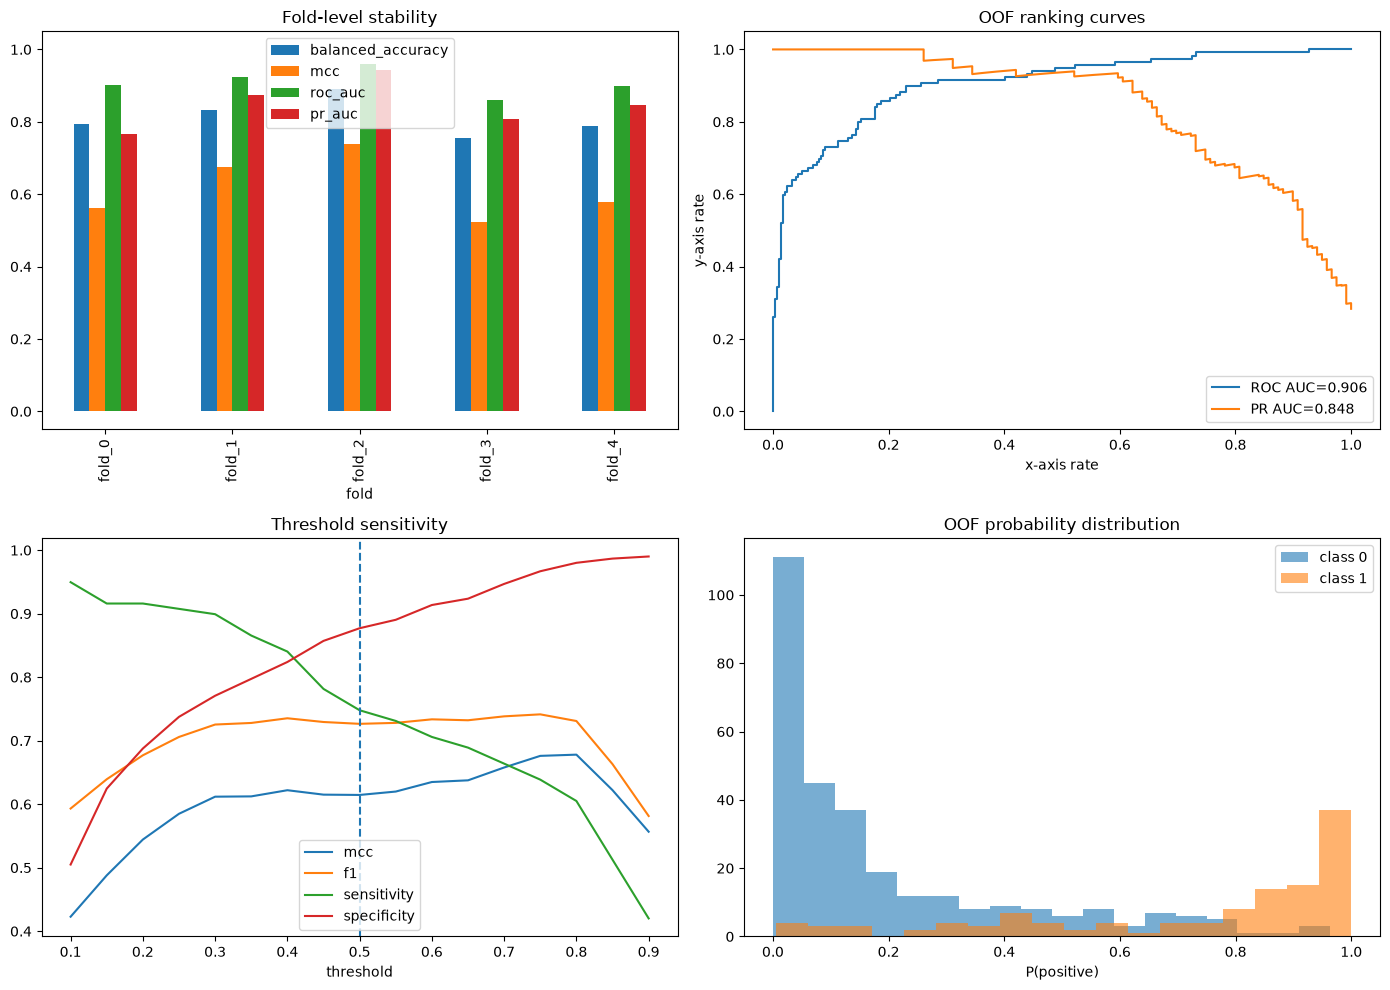

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fold_metrics.set_index("fold")[["balanced_accuracy", "mcc", "roc_auc", "pr_auc"]].plot.bar(ax=axes[0,0])
axes[0,0].set_title("Fold-level stability"); axes[0,0].set_ylim(-0.05, 1.05)

fpr, tpr, _ = roc_curve(y, proba)
precision, recall, _ = precision_recall_curve(y, proba)
axes[0,1].plot(fpr, tpr, label=f"ROC AUC={auc(fpr,tpr):.3f}")
axes[0,1].plot(recall, precision, label=f"PR AUC={result.aggregate_metrics['pr_auc']:.3f}")
axes[0,1].set(xlabel="x-axis rate", ylabel="y-axis rate", title="OOF ranking curves")
axes[0,1].legend()

threshold_report.set_index("threshold")[["mcc", "f1", "sensitivity", "specificity"]].plot(ax=axes[1,0])
axes[1,0].axvline(0.5, linestyle="--"); axes[1,0].set_title("Threshold sensitivity")
for cls in (0,1):
    axes[1,1].hist(proba[y==cls], bins=18, alpha=0.6, label=f"class {cls}")
axes[1,1].set(title="OOF probability distribution", xlabel="P(positive)"); axes[1,1].legend()
plt.tight_layout()
FIGURE_COUNT = 1


In [6]:
DEMO_CHECKS = {
    "five_folds": result.n_splits == 5,
    "complete_oof": result.metadata["oof_complete"] is True,
    "all_metrics_present": set(metrics) == set(result.aggregate_metrics),
    "sample_weights_exercised": dataset.sample_weight is not None,
    "threshold_report_complete": len(threshold_report) == 17,
    "errors_traceable": set(worst_errors.columns) >= {"sample_id", "y_true", "y_pred", "p_positive"},
    "finite_metrics": all(np.isfinite(v) for v in result.aggregate_metrics.values()),
    "figure_created": FIGURE_COUNT == 1,
}
assert all(DEMO_CHECKS.values()), DEMO_CHECKS
DEMO_CHECKS


{'five_folds': True,
 'complete_oof': True,
 'all_metrics_present': True,
 'sample_weights_exercised': True,
 'threshold_report_complete': True,
 'errors_traceable': True,
 'finite_metrics': True,
 'figure_created': True}